# **Introdução à Econometria (Jeffrey Wooldridge) utilizando o Python**

### Autor: João Vitor da Silva Correia
### Data: 24/09/2024

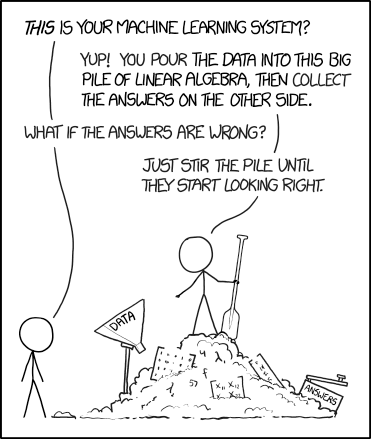

Neste notebook (em construção) estarei resolvendo os exercícios práticos do livro “Introdução à Econometria: Uma Abordagem Moderna” de Jeffrey Wooldridge, utilizando o Python.

O livro do Wooldridge é uma grande referência no campo da econometria, oferecendo uma abordagem moderna e acessível. Ele abrange desde os fundamentos estatísticos até as técnicas mais tradicionais de econometria, sempre com exemplos práticos que facilitam a aplicação dos conceitos em dados reais, incentivando a análise empírica e o uso de ferramentas para a implementação dos modelos discutidos.





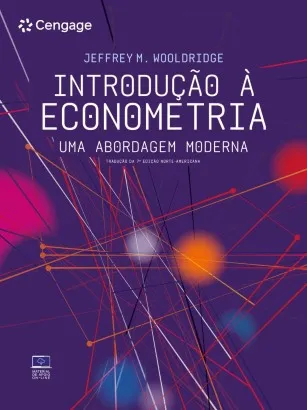

### Instalação e importação das bibliotecas necessárias

In [ ]:
#instalação das bibliotecas
!pip install wooldridge
!pip install pandasql #biblioteca permite executar consultas sql sobre dataframes utilizando sintaxe sql

In [27]:

import pandas as pd
import wooldridge #vamos utilizar uma biblioteca pronta do Livro em python (Data sets from Introductory Econometrics: A Modern Approach (7th ed, J.M. Wooldridge)
import pandasql as psql #biblioteca sql no pandas

## **CAPÍTULO 1**


### **1.1 Utilize os dados contidos em WAGE1.RAW para fazer este exercício:**


In [4]:
wooldridge.data('wage1', description=True) #para mostrar a descrição do dataset
wage1 = wooldridge.data('wage1') #para carregar o dataset desejado
wage1.head() #para mostrar as primeiras linhas do dataset

name of dataset: wage1
no of variables: 24
no of observations: 526

+----------+---------------------------------+
| variable | label                           |
+----------+---------------------------------+
| wage     | average hourly earnings         |
| educ     | years of education              |
| exper    | years potential experience      |
| tenure   | years with current employer     |
| nonwhite | =1 if nonwhite                  |
| female   | =1 if female                    |
| married  | =1 if married                   |
| numdep   | number of dependents            |
| smsa     | =1 if live in SMSA              |
| northcen | =1 if live in north central U.S |
| south    | =1 if live in southern region   |
| west     | =1 if live in western region    |
| construc | =1 if work in construc. indus.  |
| ndurman  | =1 if in nondur. manuf. indus.  |
| trcommpu | =1 if in trans, commun, pub ut  |
| trade    | =1 if in wholesale or retail    |
| services | =1 if in services indus.  

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
0,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,0,1.131402,4,0
1,3.24,12,22,2,0,1,1,3,1,0,...,0,0,1,0,0,0,1,1.175573,484,4
2,3.00,11,2,0,0,0,0,2,0,0,...,0,1,0,0,0,0,0,1.098612,4,0
3,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,0,1,0,1.791759,1936,784
4,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1.667707,49,4




### **( i ) Encontre o nível médio de escolaridade na amostra. Quais são o maior e o menor número de anos de educação formal?**

In [5]:
print("Média:", round(wage1.educ.mean(),2))
print("Maior valor:", wage1.educ.min())
print("Menor valor:", wage1.educ.max())

Média: 12.56
Maior valor: 0
Menor valor: 18


*R: O nível médio de escolaridade da amostra é 13 anos. 18 e 0 são os extremos.*

### **( ii ) Encontre o salário médio por hora na amostra. Ele parece ser alto ou baixo?**

In [ ]:
print("Média:", round(wage1.wage.mean(),2))

Média: 5.9


*R: O salário médio por hora é de US$ 5.90, e parece ser baixo para os patamares atuais. Lembrando que o salário está em doláres de 1976.*







###**( iii ) Os dados sobre salários estão relatados em dólares de 1976. Usando o Economic Report of the President (de 2004 ou posterior) obtenha e relate o Índice de Preços ao Consumidor (IPC) para os anos de 1976 e 2003.**

Colete os dados do CPI (Consumer Price Index) dos Estados Unidos para os anos de 1976, 2003 e 2024 através desse link: [Consumer Price Index, 1913](https://www.minneapolisfed.org/about-us/monetary-policy/inflation-calculator/consumer-price-index-1913-)

### **( iv ) Use os valores do IPC da parte (iii) para encontrar a média de salário médio em dólares de 2003. E agora, o salário médio por hora parece razoável?**

In [ ]:
cpi1976 = 56.9

cpi2003 = 184.0

cpi2024 = 314.4

wage2003 = (wage1.wage.mean())*(cpi2003/cpi1976)#deflacionamento de 1976 para 2003
wage2024 = (wage1.wage.mean())*(cpi2024/cpi1976)#deflacionamento de 1976 para 2024

print(round(wage1.wage.mean(),2)) #1976
print(wage2003.round(2))#2003
print(wage2024.round(2))#2024

5.9
19.07
32.58


*R: Agora os valores dos salários médios estão mais condizentes com os respectivos anos 1976 (US\$ 5.90), 2003 (US\$ 19.07) e 2024 (US\$ 32.58)*



### **( v ) Quantas mulheres estão na amostra? Quantos homens?**

In [ ]:

print(wage1.female.value_counts()[0], "Homens")
print(wage1.female.value_counts()[1], "Mulheres")

274 Homens
252 Mulheres


### **1.2 Use os dados de BWGHT.RAW para responder a esta pergunta.**

In [7]:
wooldridge.data('bwght', description=True) #para mostrar a descrição do dataset
bwght = wooldridge.data('bwght') #para carregar o dataset desejado
bwght.head() #para mostrar as primeiras linhas do dataset

name of dataset: bwght
no of variables: 14
no of observations: 1388

+----------+--------------------------------+
| variable | label                          |
+----------+--------------------------------+
| faminc   | 1988 family income, $1000s     |
| cigtax   | cig. tax in home state, 1988   |
| cigprice | cig. price in home state, 1988 |
| bwght    | birth weight, ounces           |
| fatheduc | father's yrs of educ           |
| motheduc | mother's yrs of educ           |
| parity   | birth order of child           |
| male     | =1 if male child               |
| white    | =1 if white                    |
| cigs     | cigs smked per day while preg  |
| lbwght   | log of bwght                   |
| bwghtlbs | birth weight, pounds           |
| packs    | packs smked per day while preg |
| lfaminc  | log(faminc)                    |
+----------+--------------------------------+

J. Mullahy (1997), “Instrumental-Variable Estimation of Count Data
Models: Applications to Models of C

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,lbwght,bwghtlbs,packs,lfaminc
0,13.5,16.5,122.300003,109,12.0,12.0,1,1,1,0,4.691348,6.8125,0.0,2.602690
1,7.5,16.5,122.300003,133,6.0,12.0,2,1,0,0,4.890349,8.3125,0.0,2.014903
2,0.5,16.5,122.300003,129,NaN,12.0,2,0,0,0,4.859812,8.0625,0.0,-0.693147
3,15.5,16.5,122.300003,126,12.0,12.0,2,1,0,0,4.836282,7.8750,0.0,2.740840
4,27.5,16.5,122.300003,134,14.0,12.0,2,1,1,0,4.897840,8.3750,0.0,3.314186


### **( i ) Quantas mulheres estão na amostra, e quantas informam terem fumado durante a gravidez?**

In [49]:
#quantidade de mulheres na amostra
print(len(bwght)) #outra forma de acessar o primeiro valor da tupla



#estou criando uma query --> comando no sql.  A query se chama mulheres_fumantes
mulheres_fumantes = """SELECT count(*) as cigs
            FROM bwght
            WHERE cigs > 0 """

mulheres_fumantes = psql.sqldf(mulheres_fumantes, locals()) #locals permite que o sqldf acesse as variáveis do dataframe dentro do ambiente de execução atual


print(mulheres_fumantes.to_string(index=False))  #aqui não imprime o índice da linha do dataframe

1388
 cigs
  212


*R: A amostra apresenta 1388 mulheres, tendo 212 mulheres que fumaram durante a gravidez.*

### **( ii ) Qual é a média de cigarros fumados por dia? A média é um bom índice da mulher “típica” neste caso? Explique.**



In [47]:
round(bwght.cigs.mean())

2

*R: A média é de 2 cigarros por dia. Não é uma boa medida, pois essa média leva em consideração as mulheres que não fumam, essas por sua vez são grande maioria na amostra. Desse modo, o correto é utilizar uma amostra apenas com as mulheres fumantes para calcular a média.*

### **( iii ) Entre as mulheres que fumaram durante a gravidez, qual é a média de cigarros fumados por dia? Como isso se compara com sua resposta da parte ( ii ), e por quê?**

In [53]:
print(round(bwght[bwght.cigs > 0].cigs.mean())) #média apenas das mulheres que fumam
print(round(bwght.cigs.mean())) #média geral

14
2


*R: A nova média é 14 cigarros por dia, a média agora faz mas sentido, dado que só temos mulheres fumantes nessa nova amostra.*

### **( iv ) Encontre a média de fatheduc na amostra. Por que somente 1.192 observações são usadas para calcular a média?**

In [62]:
#1º passo é verificar o dataset original
bwght.fatheduc

,fatheduc
0,12.0
1,6.0
2,NaN
3,12.0
4,14.0
...,...
1383,12.0
1384,NaN
1385,18.0
1386,NaN


In [68]:
#2º passo tratar os valores faltantes (missing)
bwght.fatheduc.dropna()


,fatheduc
0,12.0
1,6.0
3,12.0
4,14.0
5,12.0
...,...
1381,14.0
1382,16.0
1383,12.0
1385,18.0


In [79]:
#3º agora sim podemos fazer a média
round(bwght.fatheduc.describe()) #estatísticas descritivas, algo parecido com o proc means, round(,2) corresponde a 2 casas decimais

,fatheduc
count,1192.0
mean,13.0
std,3.0
min,1.0
25%,12.0
50%,12.0
75%,16.0
max,18.0


*R: A média da escolaridade do pai na amostra é de 13 anos. A amostra possui 1192 observações porque haviam valores missing que foram retirados, o que reduziu o número da amostra.*



### **( v ) Relate a renda familiar média e seu desvio-padrão em dólares.**

In [77]:
round(bwght.faminc.describe(),2) #estatísticas descritivas, algo parecido com o proc means

,faminc
count,1388.00
mean,29.03
std,18.74
min,0.50
25%,14.50
50%,27.50
75%,37.50
max,65.00


*R: A renda familiar média da amostra é US\$ 29.03 mil, o desvio-padrão US\$ 18.74 mil (lembrando que a variável faminc corresponde a renda familiar em milhares de dólares).*